# RAG Experimentation & Analysis

This notebook demonstrates the resume RAG pipeline, evaluates retrieval quality,
and benchmarks latency for the profile matching assignment.

In [1]:
import json
import importlib
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Find project root (works whether kernel starts in /notebooks or project root)
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "resume_rag.py").exists() and (ROOT.parent / "resume_rag.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Always load latest code (important after job_matcher.py fixes)
import config
import resume_rag
import job_matcher
import tools.resume_loader as resume_loader

importlib.reload(config)
importlib.reload(resume_loader)
importlib.reload(resume_rag)
importlib.reload(job_matcher)

from config import JOB_DESCRIPTIONS_DIR, RESUMES_DIR
from job_matcher import JobMatcher
from resume_rag import ResumeRAG
from tools.resume_loader import list_resumes, load_all_resumes

## 1. Dataset Overview

In [2]:
listing = list_resumes(RESUMES_DIR)
print(f"Resume count: {listing['count']}")
print(f"Directory: {listing['directory']}")

batch = load_all_resumes(RESUMES_DIR)
print(f"Loaded: {batch['loaded_count']}, Failed: {batch['failed_count']}")

rows = []
for doc in batch["documents"]:
    m = doc["metadata"]
    rows.append({
        "name": m["name"],
        "experience_years": m["experience_years"],
        "skill_count": len(m["skills"]),
        "sections": ", ".join(m["section_names"]),
    })
df_meta = pd.DataFrame(rows)
df_meta.head(10)

Resume count: 34
Directory: D:\D\profileMatching\resumes
Loaded: 34, Failed: 0


,name,experience_years,skill_count,sections
0,Adam Young,12.0,6,"summary, experience, education, skills, projects"
1,Alice Smith,8.0,7,"summary, experience, education, skills, projects"
2,Bella King,4.0,6,"summary, experience, education, skills, projects"
3,Bob Johnson,5.0,7,"summary, experience, education, skills, projects"
4,Carlos Williams,6.0,6,"summary, experience, education, skills, projects"
5,Chris Wright,6.0,6,"summary, experience, education, skills, projects"
6,Deepa Scott,5.0,6,"summary, experience, education, skills, projects"
7,Diana Brown,7.0,7,"summary, experience, education, skills, projects"
8,Elena Green,8.0,7,"summary, experience, education, skills, projects"
9,Ethan Jones,9.0,6,"summary, experience, education, skills, projects"


## 2. Build Vector Index

In [3]:
rag = ResumeRAG()
rag.reset_index()

index_start = time.perf_counter()
index_result = rag.index_resumes(RESUMES_DIR)
index_latency = time.perf_counter() - index_start

print(json.dumps(index_result, indent=2))
print(f"\nTotal indexing time: {index_latency:.2f}s")
rag.get_stats()

{
  "success": true,
  "documents_indexed": 34,
  "chunks_indexed": 170,
  "failed_count": 0,
  "failures": [],
  "latency_seconds": 10.752,
  "collection": "resumes",
  "persist_dir": "D:\\D\\profileMatching\\data\\chroma_db"
}

Total indexing time: 10.75s


{'success': True,
 'collection': 'resumes',
 'chunk_count': 170,
 'persist_dir': 'D:\\D\\profileMatching\\data\\chroma_db',
 'embedding_provider': 'chroma',
 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2'}

## 3. Semantic Search Demo

In [4]:
query = "Senior Python machine learning engineer with AWS and Docker experience"
search_result = rag.query(query, top_k=5)

for i, hit in enumerate(search_result["results"], 1):
    meta = hit["metadata"]
    print(f"{i}. {meta['candidate_name']} | section={meta['section']} | sim={hit['similarity']}")
    print(f"   {hit['text'][:120]}...\n")

1. Alice Smith | section=skills | sim=0.7351
   Python, Machine Learning, TensorFlow, PyTorch, AWS, Docker, SQL...

2. Elena Green | section=skills | sim=0.7351
   Python, Machine Learning, TensorFlow, PyTorch, AWS, Docker, SQL...

3. Kevin Lee | section=skills | sim=0.7351
   Python, Machine Learning, TensorFlow, PyTorch, AWS, Docker, SQL...

4. Uma Harris | section=skills | sim=0.7351
   Python, Machine Learning, TensorFlow, PyTorch, AWS, Docker, SQL...

5. Elena Green | section=experience | sim=0.7149
   Senior Senior Python ML Engineer | TechCorp 31 2018-Present - Built production ML pipelines and recommendation systems. ...



## 4. Job Matching (Hybrid Search)

In [5]:
matcher = JobMatcher(rag)
jd_path = JOB_DESCRIPTIONS_DIR / "senior_python_ml_engineer.json"

match_start = time.perf_counter()
match_result = matcher.match_job_file(jd_path)
match_latency = time.perf_counter() - match_start

print(f"Job: {match_result.get('job_title')}")
print(f"Match latency: {match_latency:.3f}s\n")

for m in match_result["top_matches"][:5]:
    print(f"{m['candidate_name']:20s} score={m['match_score']} skills={m['matched_skills'][:4]}")

Job: Senior Python ML Engineer
Match latency: 0.450s

Elena Green          score=84 skills=['Python', 'Machine Learning', 'TensorFlow', 'PyTorch']
Alice Smith          score=84 skills=['Python', 'Machine Learning', 'TensorFlow', 'PyTorch']
Kevin Lee            score=84 skills=['Python', 'Machine Learning', 'TensorFlow', 'PyTorch']
Uma Harris           score=84 skills=['Python', 'Machine Learning', 'TensorFlow', 'PyTorch']
Nina Taylor          score=50 skills=['Python', 'Machine Learning', 'AWS', 'Docker']


## 5. Retrieval Accuracy Evaluation

We define expected top candidates per job (based on role profiles in synthetic data)
and measure whether they appear in the top-K results.

In [6]:
# Ground truth: job -> keywords that should match candidate role profiles
EVAL_CASES = {
    "senior_python_ml_engineer.json": ["ml engineer", "machine learning", "tensorflow", "pytorch"],
    "full_stack_developer.json": ["full stack", "react", "node.js"],
    "devops_engineer.json": ["devops", "kubernetes", "terraform"],
    "data_scientist.json": ["data scientist", "pandas", "scikit"],
    "nlp_engineer.json": ["nlp", "pytorch", "fastapi"],
    "backend_java_developer.json": ["java", "spring", "microservices"],
}

K = 10
eval_rows = []

for job_file, keywords in EVAL_CASES.items():
    result = matcher.match_job_file(JOB_DESCRIPTIONS_DIR / job_file, top_k=K)
    top_names = [m["candidate_name"].lower() for m in result.get("top_matches", [])]
    top_text = " ".join(
        " ".join(m.get("relevant_excerpts", [])) for m in result.get("top_matches", [])
    ).lower()

    hits = sum(1 for kw in keywords if any(kw in n or kw in top_text for n in top_names))
    accuracy = hits / len(keywords) if keywords else 0

    eval_rows.append({
        "job": job_file.replace(".json", ""),
        "keyword_hits": hits,
        "keyword_total": len(keywords),
        "accuracy": round(accuracy * 100, 1),
        "top_candidate": result["top_matches"][0]["candidate_name"] if result.get("top_matches") else "N/A",
        "top_score": result["top_matches"][0]["match_score"] if result.get("top_matches") else 0,
    })

df_eval = pd.DataFrame(eval_rows)
df_eval

,job,keyword_hits,keyword_total,accuracy,top_candidate,top_score
0,senior_python_ml_engineer,4,4,100.0,Elena Green,84
1,full_stack_developer,3,3,100.0,Bob Johnson,80
2,devops_engineer,3,3,100.0,Diana Brown,85
3,data_scientist,3,3,100.0,Carlos Williams,80
4,nlp_engineer,3,3,100.0,Fatima Garcia,80
5,backend_java_developer,3,3,100.0,Yuki Hall,90


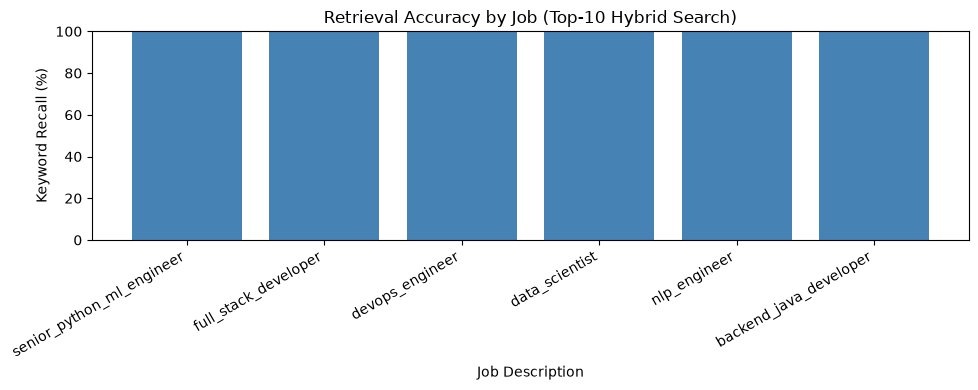

Mean accuracy: 100.0%


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_eval["job"], df_eval["accuracy"], color="steelblue")
ax.set_ylabel("Keyword Recall (%)")
ax.set_xlabel("Job Description")
ax.set_title("Retrieval Accuracy by Job (Top-10 Hybrid Search)")
ax.set_ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Mean accuracy: {df_eval['accuracy'].mean():.1f}%")

## 6. Latency Benchmarks

In [8]:
latencies = {"index_build": [], "semantic_query": [], "job_match": []}
N = 5

for _ in range(N):
    t0 = time.perf_counter()
    rag.query("Python developer with cloud experience", top_k=10)
    latencies["semantic_query"].append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    matcher.match_job_file(jd_path)
    latencies["job_match"].append(time.perf_counter() - t0)

latencies["index_build"] = [index_latency]

df_latency = pd.DataFrame({
    "operation": ["Index Build (34 resumes)", "Semantic Query", "Job Match"],
    "mean_s": [
        index_latency,
        sum(latencies["semantic_query"]) / N,
        sum(latencies["job_match"]) / N,
    ],
    "min_s": [
        index_latency,
        min(latencies["semantic_query"]),
        min(latencies["job_match"]),
    ],
    "max_s": [
        index_latency,
        max(latencies["semantic_query"]),
        max(latencies["job_match"]),
    ],
})
df_latency

,operation,mean_s,min_s,max_s
0,Index Build (34 resumes),10.752628,10.752628,10.752628
1,Semantic Query,0.562899,0.377431,0.762175
2,Job Match,0.748482,0.508433,0.996074


## 7. Hybrid vs Semantic-Only Comparison

In [9]:
hybrid = matcher.match_job_file(jd_path, semantic_weight=0.65, keyword_weight=0.35)
semantic_only = matcher.match_job_file(jd_path, semantic_weight=1.0, keyword_weight=0.0)

comparison = pd.DataFrame({
    "rank": range(1, 6),
    "hybrid_candidate": [m["candidate_name"] for m in hybrid["top_matches"][:5]],
    "hybrid_score": [m["match_score"] for m in hybrid["top_matches"][:5]],
    "semantic_candidate": [m["candidate_name"] for m in semantic_only["top_matches"][:5]],
    "semantic_score": [m["match_score"] for m in semantic_only["top_matches"][:5]],
})
comparison

,rank,hybrid_candidate,hybrid_score,semantic_candidate,semantic_score
0,1,Elena Green,84,Elena Green,76
1,2,Alice Smith,84,Alice Smith,75
2,3,Kevin Lee,84,Kevin Lee,75
3,4,Uma Harris,84,Uma Harris,75
4,5,Nina Taylor,50,Nina Taylor,50


## 8. Error Handling Demo

In [10]:
from tools.resume_loader import validate_file, load_resume

# Invalid file type
print("Invalid extension:", validate_file("README.md"))

# Missing file
print("Missing file:", validate_file("resumes/nonexistent.txt"))

# Empty query
print("Empty query:", rag.query(""))

Invalid extension: {'success': False, 'tool': 'validate_file', 'error': {'message': 'File not found: README.md', 'code': 'FILE_NOT_FOUND'}, 'valid': False, 'path': 'README.md'}
Missing file: {'success': False, 'tool': 'validate_file', 'error': {'message': 'File not found: resumes\\nonexistent.txt', 'code': 'FILE_NOT_FOUND'}, 'valid': False, 'path': 'resumes\\nonexistent.txt'}
Empty query: {'success': False, 'error': {'message': 'Query text is empty', 'code': 'EMPTY_QUERY'}}
